# Lab 2: Skala Hounsfielda i Okienkowanie w Tomografii Komputerowej (CT)

## Wprowadzenie teoretyczne
W tomografii komputerowej (TK) surowe wartości pikseli (tzw. *stored values* lub *raw pixels*) zapisane w pliku DICOM nie mówią nam bezpośrednio o właściwościach fizycznych tkanek. Aby uzyskać obiektywną miarę gęstości radiologicznej, stosujemy **skalę Hounsfielda (HU)**.

### 1. Skala Hounsfielda (HU)
Skala opiera się na liniowym współczynniku osłabienia promieniowania rentgenowskiego dla danej tkanki ($\mu$) w odniesieniu do wody i powietrza:
$$HU = 1000 \cdot \frac{\mu - \mu_{woda}}{\mu_{woda} - \mu_{powietrze}}$$
Ponieważ $\mu_{powietrze} \approx 0$, wzór upraszcza się do:
$$HU = 1000 \cdot \frac{\mu - \mu_{woda}}{\mu_{woda}}$$
W praktyce pliki DICOM zawierają współczynniki przeliczeniowe w nagłówku: **Rescale Slope ($m$)** oraz **Rescale Intercept ($b$)**:
$$HU = \text{pixel\_value} \cdot m + b$$

### 2. Okienkowanie (Windowing / Leveling)
Ludzkie oko potrafi rozróżnić zaledwie ok. 30–256 odcieni szarości, tymczasem zakres skali Hounsfielda w TK wynosi od -1000 HU (powietrze) do ponad +3000 HU (kości). Aby wyświetlić obraz na monitorze, musimy zmapować ten szeroki zakres na 256 odcieni szarości za pomocą dwóch parametrów:
- **Poziom okna (Window Level / Center - WL):** Środek zakresu HU, który chcemy uwidocznić.
- **Szerokość okna (Window Width - WW):** Rozpiętość skali HU zawartej w oknie.

$b$ (Rescale Intercept) – Przesunięcie (Offset): Główny powód istnienia tego parametru jest informatyczny. Skala Hounsfielda wymaga wartości ujemnych, z powietrzem na poziomie -1000 HU i tkanką tłuszczową wokół -100 HU. Jednak przetworniki analogowo-cyfrowe (ADC) w skanerach oraz formaty zapisu w DICOM często generują i przechowują macierze jako liczby całkowite bez znaku (unsigned integers, np. w zakresie od 0 do 4095). Parametr $b$ pozwala skompensować ten problem. Jeśli skaner zapisze fizyczne powietrze jako wartość 0, to w nagłówku DICOM zapisze $b = -1000$. Podczas wczytywania przesunie to całą skalę w dół ($0 \cdot 1 - 1000 = -1000$ HU), przywracając poprawne wartości ujemne.

$m$ (Rescale Slope) – Nachylenie (Krok skalowania): Definiuje, ile jednostek Hounsfielda reprezentuje pojedynczy cyfrowy "krok" (jednostka) zapisany przez detektor. W większości współczesnych skanerów medycznych wynosi on $1$ (każdy 1 stopień na surowej matrycy to 1 HU). Jeśli jednak producent zastosował w urządzeniu nietypowy przetwornik lub dokonał kompresji/zmiany mapowania danych przed zapisem, parametr $m$ pozwala "rozciągnąć" lub "ścisnąć" surowe wartości, aby odstęp między referencyjnym powietrzem a wodą znów wynosił dokładnie 1000 HU.

Dzięki rozdzieleniu danych na surową macierz oraz parametry Rescale Slope ($m$) i Rescale Intercept ($b$), plik DICOM jest całkowicie niezależny od producenta sprzętu (Siemens, GE, Canon). Skaner może używać wewnętrznie dowolnej reprezentacji binarnej i dowolnych zakresów, a fizyk medyczny – stosując tę prostą transformację liniową – zawsze otrzyma znormalizowane wartości gęstości radiologicznej, na których można bezpiecznie opierać diagnostykę i planowanie radioterapii.

In [9]:
# Import bibliotek
import pydicom
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 6)

## Krok 1: Wczytanie pliku TK i konwersja do jednostek Hounsfielda

In [13]:
# Wczytanie testowego pliku CT
from pydicom.data import get_testdata_files
filename = get_testdata_files("CT_small.dcm")[0]
ds = pydicom.dcmread(filename)

# Pobranie surowej macierzy
raw_pixels = ds.pixel_array

# Odczytanie parametrów przeliczeniowych (Slope i Intercept)
# Jeśli tagi nie występują, przyjmujemy domyślnie m=1, b=0
slope = getattr(ds, 'RescaleSlope', 1)
intercept = getattr(ds, 'RescaleIntercept', 0)

# Konwersja do jednostek Hounsfielda
hu_image = raw_pixels.astype(np.float32) * slope + intercept

print(f"Minimalna wartość HU: {np.min(hu_image):.1f}")
print(f"Maksymalna wartość HU: {np.max(hu_image):.1f}")

Minimalna wartość HU: -896.0
Maksymalna wartość HU: 1167.0


## Krok 2: Analiza histogramu wartości HU

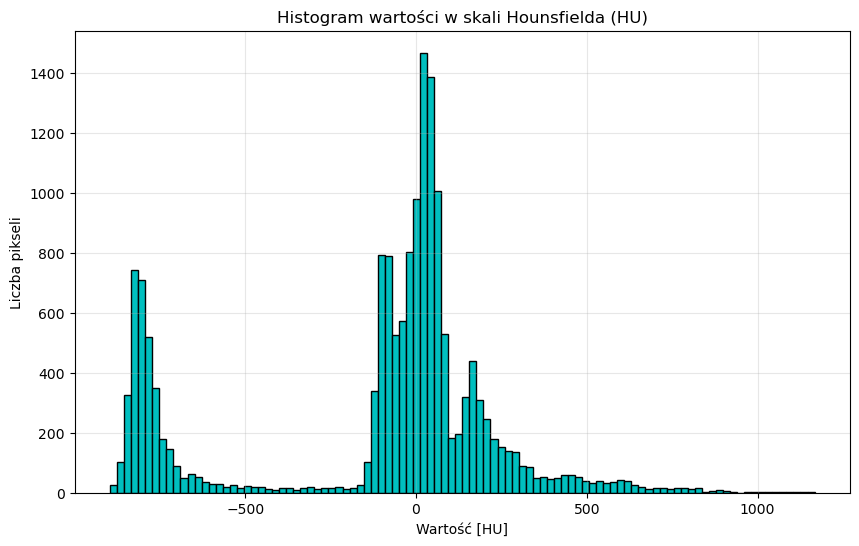

In [22]:
# Rysujemy histogram wartości Hounsfielda
plt.hist(hu_image.flatten(), bins=100, color='c', edgecolor='black')
plt.title('Histogram wartości w skali Hounsfielda (HU)')
plt.xlabel('Wartość [HU]')
plt.ylabel('Liczba pikseli')
plt.grid(True, alpha=0.3)
plt.show()

## Krok 3: Implementacja funkcji okienkowania (Windowing)

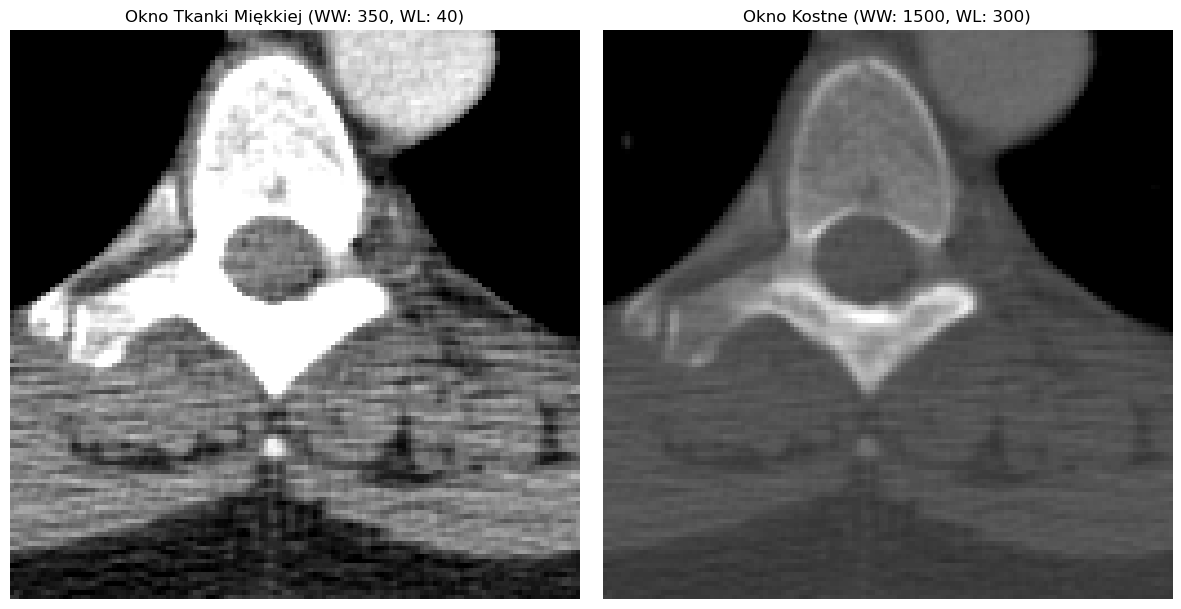

In [25]:
def apply_window(image, window_width, window_level):
    """
    Funkcja przekształcająca obraz HU na zakres 0-255 (skala szarości)
    zgodnie z zadana szerokością (WW) i poziomem (WL) okna.
    """
    min_val = window_level - window_width / 2
    max_val = window_level + window_width / 2
    
    # Obcięcie wartości spoza zakresu okna (clipping)
    windowed = np.clip(image, min_val, max_val)
    
    # Przeskalowanie do zakresu 0 - 255
    windowed = ((windowed - min_val) / (max_val - min_val)) * 255.0
    
    return windowed.astype(np.uint8)

# Definiujemy popularne okna kliniczne:
# 1. Okno tkanki miękkiej (Soft Tissue): WW = 350, WL = 40
# 2. Okno kostne (Bone): WW = 1500, WL = 300

img_soft = apply_window(hu_image, window_width=350, window_level=40)
img_bone = apply_window(hu_image, window_width=1500, window_level=300)

# Wyświetlenie porównania
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_soft, cmap='gray')
axes[0].set_title('Okno Tkanki Miękkiej (WW: 350, WL: 40)')
axes[0].axis('off')

axes[1].imshow(img_bone, cmap='gray')
axes[1].set_title('Okno Kostne (WW: 1500, WL: 300)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

--- 
# ZADANIA SAMODZIELNE DLA STUDENTÓW

### Zadanie 1: Weryfikacja wartości referencyjnych HU
Wiedząc, że woda ma około 0 HU, a powietrze -1000 HU:
1. Znajdź w macierzy `hu_image` minimalną wartość i sprawdź, czy odpowiada ona powietrzu.
2. Oblicz średnią wartość HU dla pikseli, które mieszczą się w zakresie od -10 do +10 HU (reprezentujących m.in. wodę lub płyn mózgowo-rdzeniowy).

In [30]:
# Miejsce na Twój kod (Zadanie 1):



### Zadanie 2: Okno płucne (Lung Window)
Standardowe okno do oceny płuc w TK klatki piersiowej charakteryzuje się następującymi parametrami:
- Szerokość okna (WW) = 1500 HU
- Poziom okna (WL) = -600 HU

**Polecenie:** Użyj wcześniej napisanej funkcji `apply_window`, aby wygenerować i wyświetlić obraz w okienku płucnym. Zwróć uwagę, co dzieje się z pęcherzykami płucnymi i tkankami otaczającymi.

In [ ]:
# Miejsce na Twój kod (Zadanie 2):



### Zadanie 3: Interaktywna analiza wielu okien
Napisz skrypt, który tworzy wykres typu *subplot* składający się z 4 pól (siatka 2x2), przedstawiający ten sam przekrój TK w czterech różnych ustawieniach okna:
1. Okno mózgowe (Brain): WW = 80, WL = 40
2. Okno śródpiersia (Mediastinum): WW = 350, WL = 50
3. Okno kostne (Bone): WW = 1500, WL = 300
4. Okno wątrobowe (Liver): WW = 150, WL = 30

Podpisz każdy wykres odpowiednim tytułem.

In [ ]:
# Miejsce na Twój kod (Zadanie 3):

